In [1]:
#Packages
import pandas as pd
import numpy as np
import re
import os
import time
import torch
import transformers
import warnings
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import BertTokenizer, BertForSequenceClassification
warnings.filterwarnings("ignore", category=UserWarning)
import matplotlib.pyplot as plt
import seaborn as sns
from getpass import getpass

In [2]:
#Sentiment Extraction
def run_finbert(df, date_col='Date', ticker_col='Stock_symbol'):
   
    #Hardware Optimization for Local CPU
    torch.set_num_threads(max(1, os.cpu_count() - 1)) 
    
    #Pretrained Weights (Using ProsusAI/finbert standard mapping)
    model_name = "ProsusAI/finbert"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)
    model.eval() 
    
    results = [] #Placeholder for appending results
    start_time = time.time() #Measures time taken to execute
    
    #Native PyTorch Forward Pass Loop (Sequential Batch Size = 1)
    for idx, (_, row) in enumerate(df.iterrows(), 1):
        text_input = str(row['finbert_input'])
        
        #Extracts metadata
        ticker = row.get(ticker_col, 'UNKNOWN')
        date_stamp = row.get(date_col, 'UNKNOWN')
        
        #Tokenize sequence down to a maximum sequence layer of 512
        inputs = tokenizer(
            text_input, 
            padding=True, 
            truncation=True, 
            max_length=512, 
            return_tensors="pt"
        )
        
        #DeactivateS gradient calculations to maintain low CPU memory footprints
        with torch.no_grad():
            outputs = model(**inputs)
            probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1).numpy()[0]
            
        #ProsusAI Default Index Ordering: [0]=Positive, [1]=Negative, [2]=Neutral
        pos_p = float(probabilities[0])
        neg_p = float(probabilities[1])
        neu_p = float(probabilities[2])
        
        #Net independent variable
        net_sentiment_index = pos_p - neg_p
        
        results.append({
            'ticker': ticker,
            'date': date_stamp,
            'finbert_pos': pos_p,
            'finbert_neg': neg_p,
            'finbert_neu': neu_p,
            'finbert_net_score': net_sentiment_index
        })
        
    
    print(f"\nInference loop successfully concluded in {time.time() - start_time:.2f} seconds.")
    
    #Return results
    return pd.DataFrame(results)

In [3]:
#Cleaned Datasets
dataset_A = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\News\FinBERT_DatasetA_Processed.csv")
dataset_B = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\News\FinBERT_DatasetB_Processed.csv")

In [4]:
dataset_A.head(2)

,Date,Article_title,Stock_symbol,Article,Lsa_summary,Textrank_summary,Year,Article_Length,finbert_input,finbert_input_len
0,2023-12-16,ADSK Quantitative Stock Analysis,ADSK,Below is Validea's guru fundamental report for...,Below is Validea's guru fundamental report for...,"Of the 22 guru strategies we follow, ADSK rate...",2023,2968,TITLE: ADSK Quantitative Stock Analysis | TARG...,189
1,2023-12-16,Artificial Intelligence Adding New Depths to 3...,ADSK,3D scanners are used across a wide range of in...,Autodesk (ADSK) is a software company serving ...,Autodesk (ADSK) is a software company serving ...,2023,9366,TITLE: Artificial Intelligence Adding New Dept...,361


In [5]:
dataset_B.head(2)

,Date,Article_title,Stock_symbol,Article,Lsa_summary,Textrank_summary,Year,Article_Length,relevance_score,Relevance_Tier,Month,finbert_input,finbert_input_len
0,2019-01-02,The Fire Within Netflix Stock Still Burns Desp...,CMCSA,"InvestorPlace - Stock Market News, Stock Advic...",The result is many analysts are now piling int...,The result is many analysts are now piling int...,2019,5001,4,Low Impact (2-4),1,TITLE: The Fire Within Netflix Stock Still Bur...,363
1,2019-01-02,Don’t Let the Class-Action Suit Dissuade You f...,INTC,"InvestorPlace - Stock Market News, Stock Advic...",7 Stocks to Sell In January Another top compet...,7 Stocks to Sell In January Another top compet...,2019,6003,4,Low Impact (2-4),1,TITLE: Don’t Let the Class-Action Suit Dissuad...,351


In [6]:
#Set Hugging Face User Access Token to avoid access warning.
from getpass import getpass
os.environ["HF_TOKEN"] = getpass("Enter HF Token: ")

Enter HF Token:  ········


In [7]:
#Dataset A Execution
datasetA_fin_sentiment = run_finbert(dataset_A)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Inference loop successfully concluded in 31680.94 seconds.


In [8]:
datasetA_fin_sentiment.head(2)

,ticker,date,finbert_pos,finbert_neg,finbert_neu,finbert_net_score
0,ADSK,2023-12-16,0.081011,0.012903,0.906086,0.068109
1,ADSK,2023-12-16,0.220421,0.010438,0.769141,0.209983


In [9]:
#Checking Data types and verifying no missing values - Dataset A
sentiment_cols = ['finbert_pos','finbert_neg','finbert_neu','finbert_net_score']
print(datasetA_fin_sentiment[sentiment_cols].info())

<class 'pandas.DataFrame'>
RangeIndex: 60903 entries, 0 to 60902
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   finbert_pos        60903 non-null  float64
 1   finbert_neg        60903 non-null  float64
 2   finbert_neu        60903 non-null  float64
 3   finbert_net_score  60903 non-null  float64
dtypes: float64(4)
memory usage: 1.9 MB
None


In [10]:
#Range Validation - Dataset A
print("Net Sentiment Metric Summary Statistics")
display(datasetA_fin_sentiment['finbert_net_score'].describe().loc[['min', 'mean', 'max']])

Net Sentiment Metric Summary Statistics


min    -0.969835
mean   -0.050451
max     0.946921
Name: finbert_net_score, dtype: float64

In [11]:
#Dataset B Execution
datasetB_fin_sentiment = run_finbert(dataset_B)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Inference loop successfully concluded in 24145.44 seconds.


In [12]:
#Checking Data types and verifying no missing values - Dataset B
sentiment_cols = ['finbert_pos','finbert_neg','finbert_neu','finbert_net_score']
print(datasetB_fin_sentiment[sentiment_cols].info())

<class 'pandas.DataFrame'>
RangeIndex: 42724 entries, 0 to 42723
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   finbert_pos        42724 non-null  float64
 1   finbert_neg        42724 non-null  float64
 2   finbert_neu        42724 non-null  float64
 3   finbert_net_score  42724 non-null  float64
dtypes: float64(4)
memory usage: 1.3 MB
None


In [13]:
#Range Validation - Dataset B
print("Net Sentiment Metric Summary Statistics")
display(datasetB_fin_sentiment['finbert_net_score'].describe().loc[['min', 'mean', 'max']])

Net Sentiment Metric Summary Statistics


min    -0.969835
mean   -0.027797
max     0.946921
Name: finbert_net_score, dtype: float64

With net sentiment minimum for both datasets being at -0.9 and maximum being at +0.9 proves that the data contains both highly negative events and highly positive updates.

In [14]:
#The Softmax Sum Unity Check - Dataset A
checksumA = (datasetA_fin_sentiment['finbert_pos'] + datasetA_fin_sentiment['finbert_neg'] + datasetA_fin_sentiment['finbert_neu'])
is_unitary = np.allclose(checksumA, 1.0, atol=1e-5)
print(f"Softmax Unity Audit Passed: {is_unitary}")

Softmax Unity Audit Passed: True


In [15]:
#The Softmax Sum Unity Check - Dataset B
checksumB = (datasetB_fin_sentiment['finbert_pos'] + datasetB_fin_sentiment['finbert_neg'] + datasetB_fin_sentiment['finbert_neu'])
is_unitary = np.allclose(checksumB, 1.0, atol=1e-5)
print(f"Softmax Unity Audit Passed: {is_unitary}")

Softmax Unity Audit Passed: True


Because FinBERT utilizes a Softmax activation function on its final classification layer, the mathematical sum of the three output probabilities per row must equal exactly 1.0. From above audit, this is a success.

In [16]:
#The Zero-Sentiment Neutrality Check - Dataset A
#Calculate the percentage of rows where positive and negative are perfectly balanced (usually 0.0)
neutral_inertia_rate = (datasetA_fin_sentiment['finbert_net_score'] == 0.0).mean() * 100
print(f"Neutral Rate: {neutral_inertia_rate:.2f}% of the corpus is perfectly neutral.")

Neutral Rate: 0.00% of the corpus is perfectly neutral.


In [17]:
#The Zero-Sentiment Neutrality Check - Dataset B
#Calculate the percentage of rows where positive and negative are perfectly balanced (usually 0.0)
neutral_inertia_rate = (datasetB_fin_sentiment['finbert_net_score'] == 0.0).mean() * 100
print(f"Neutral Rate: {neutral_inertia_rate:.2f}% of the corpus is perfectly neutral.")

Neutral Rate: 0.00% of the corpus is perfectly neutral.


Since we calculated net sentiment, $P_{\text{Positive}} - P_{\text{Negative}}$, it is mathematically impossible for a text to sit exactly at an absolute $0.0000$ value when using high-precision floating-point numbers. This continuous feature design avoids a common bottleneck found in financial NLP studies that rely on discrete categorical labels, where generic language often leads to an over-concentration of neutral classifications.By extracting the raw, continuous difference vectors directly from FinBERT's softmax layer, the pipeline captures subtle semantic shifts across a high-variance gradient. This transforms the textual data into a continuous tracking vector that is optimized for the prediction model to map against directional S&P 500 asset price volatility.

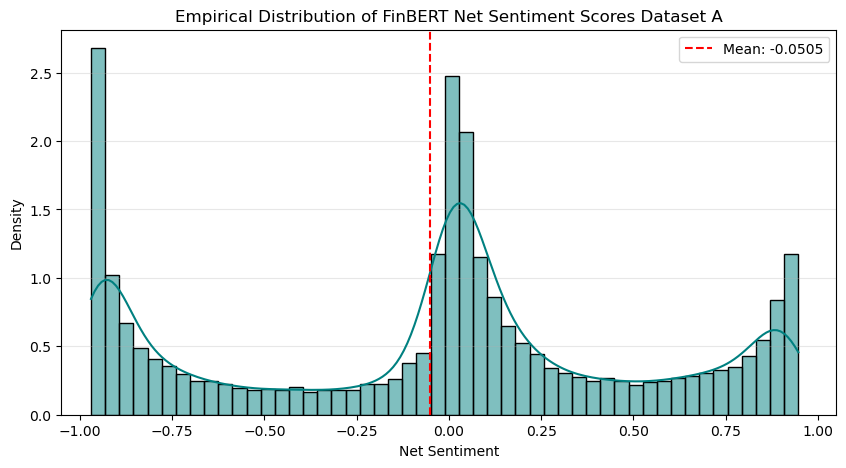

In [18]:
#The Empirical Distribution & Truncation Check (Histogram + KDE)
plt.figure(figsize=(10, 5))
#Plotting the distribution of the net score
sns.histplot(datasetA_fin_sentiment['finbert_net_score'], bins=50, kde=True, color='teal', stat='density')

#Adding a vertical line for the mean
plt.axvline(datasetA_fin_sentiment['finbert_net_score'].mean(), color='red', linestyle='--', 
            label=f"Mean: {datasetA_fin_sentiment['finbert_net_score'].mean():.4f}")

plt.title('Empirical Distribution of FinBERT Net Sentiment Scores Dataset A', fontsize=12)
plt.xlabel('Net Sentiment')
plt.ylabel('Density')
plt.xlim(-1.05, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('Empirical Distribution Dataset A.png', dpi=300)
plt.show()

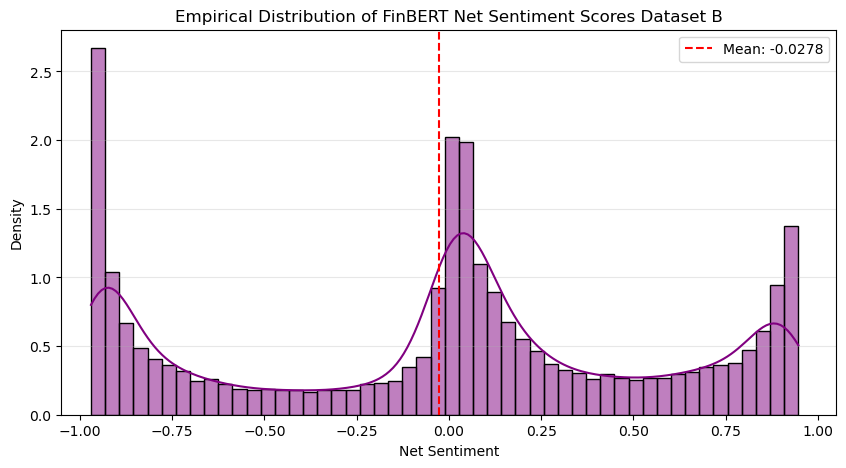

In [19]:
#The Empirical Distribution & Truncation Check (Histogram + KDE)
plt.figure(figsize=(10, 5))
#Plotting the distribution of the net score
sns.histplot(datasetB_fin_sentiment['finbert_net_score'], bins=50, kde=True, color='purple', stat='density')

#Adding a vertical line for the mean
plt.axvline(datasetB_fin_sentiment['finbert_net_score'].mean(), color='red', linestyle='--', 
            label=f"Mean: {datasetB_fin_sentiment['finbert_net_score'].mean():.4f}")

plt.title('Empirical Distribution of FinBERT Net Sentiment Scores Dataset B', fontsize=12)
plt.xlabel('Net Sentiment')
plt.ylabel('Density')
plt.xlim(-1.05, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('Empirical Distribution Dataset B.png', dpi=300)
plt.show()

This visually demonstrates that the model successfully differentiates strong sentiment from baseline noise. Nature of financial news is not always neutral and the model can clearly separate strong positive or negative market news. This will ensure the prediction model can capture this variance for stock market prediction. Looking closely at the distribution around $-0.8$ and $+0.8$, it confirms that the FinBERT model is successfully detecting strong sentiment signals instead of diluting everything toward a flat normal curve.

There is a slight difference between dataset A & B distributions, Dataset A tends to have a higher density at neutral which can be attributed to the fact that the data had more noise as dataset B was further filtered to retain only relevant news.

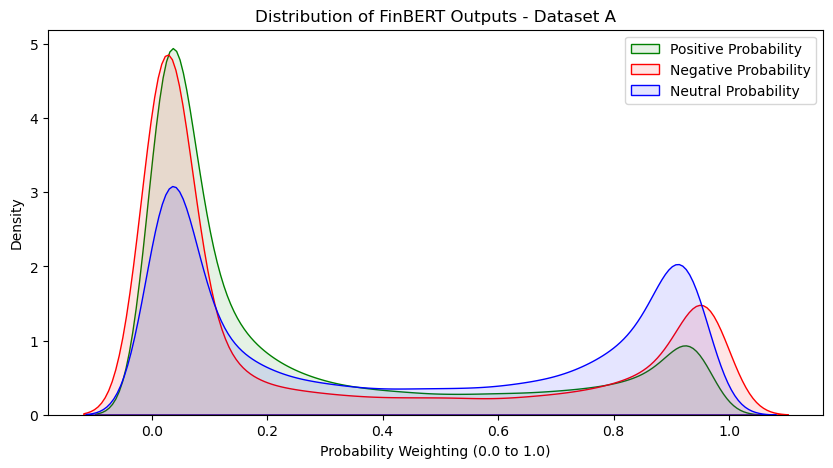

In [20]:
#The Softmax Tri-Axial Distribution (Density Plot)
plt.figure(figsize=(10, 5))
sns.kdeplot(datasetA_fin_sentiment['finbert_pos'], label='Positive Probability', color='green', fill=True, alpha=0.1)
sns.kdeplot(datasetA_fin_sentiment['finbert_neg'], label='Negative Probability', color='red', fill=True, alpha=0.1)
sns.kdeplot(datasetA_fin_sentiment['finbert_neu'], label='Neutral Probability', color='blue', fill=True, alpha=0.1)
plt.title('Distribution of FinBERT Outputs - Dataset A', fontsize=12)
plt.xlabel('Probability Weighting (0.0 to 1.0)')
plt.ylabel('Density')
plt.legend()
plt.savefig('Distribution of FinBERT Outputs - Dataset A.png', dpi=300)
plt.show()

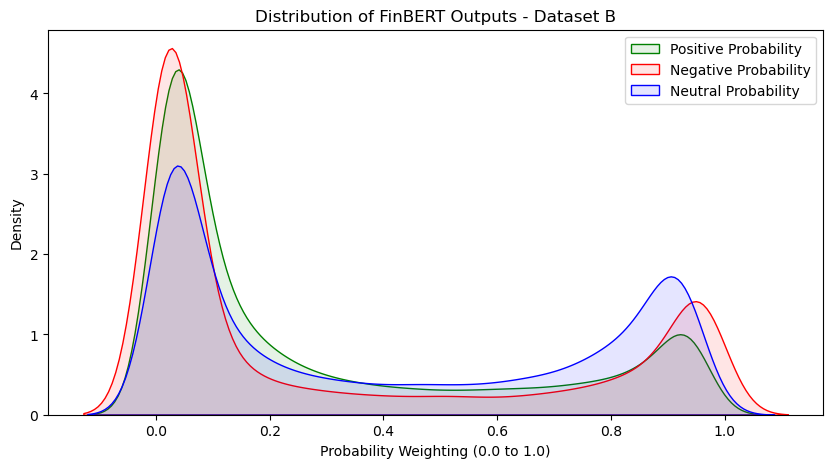

In [21]:
#The Softmax Tri-Axial Distribution (Density Plot)
plt.figure(figsize=(10, 5))
sns.kdeplot(datasetB_fin_sentiment['finbert_pos'], label='Positive Probability', color='green', fill=True, alpha=0.1)
sns.kdeplot(datasetB_fin_sentiment['finbert_neg'], label='Negative Probability', color='red', fill=True, alpha=0.1)
sns.kdeplot(datasetB_fin_sentiment['finbert_neu'], label='Neutral Probability', color='blue', fill=True, alpha=0.1)
plt.title('Distribution of FinBERT Outputs - Dataset B', fontsize=12)
plt.xlabel('Probability Weighting (0.0 to 1.0)')
plt.ylabel('Density')
plt.legend()
plt.savefig('Distribution of FinBERT Outputs - Dataset B.png', dpi=300)
plt.show()

The Softmax Tri-Axial Density Plot confirms the high parameter confidence of the classification head on the textual corpus. The probability distribution demonstrates an expected bi-modal behavior across the channels. In the low-probability spectrum (0.0 to 0.25), we observe a heavy concentration of density, indicating that when a definitive sentiment is detected, the probabilities of competing classes are successfully driven to zero.Conversely, in the high-confidence region (0.75 to 1.0), the model displays strong, unambiguous classification density for neutral factual sentences and negative risk disclosures, while extreme positive confidence displays a lower, more selective density profile. 

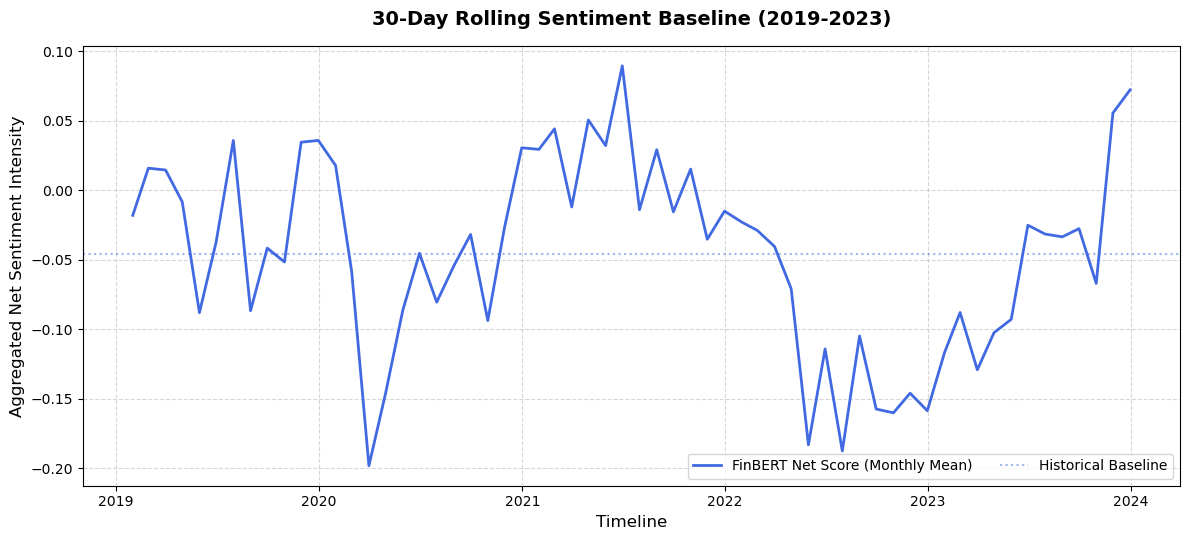

In [22]:
#Sentiment Trajectory Plot
time_df = datasetA_fin_sentiment[['date', 'finbert_net_score']].copy()
time_df['date'] = pd.to_datetime(time_df['date'])
time_df.set_index('date', inplace=True)

#Resample to Monthly Average to smooth out daily noise for a clean display
monthly_sentiment = time_df.resample('ME').mean() #Month End

plt.figure(figsize=(12, 5.5))
plt.plot(monthly_sentiment.index, monthly_sentiment['finbert_net_score'], label='FinBERT Net Score (Monthly Mean)', color='royalblue', linewidth=2)
plt.axhline(y=monthly_sentiment['finbert_net_score'].mean(), color='royalblue', linestyle=':', alpha=0.5, label='Historical Baseline')
plt.title('30-Day Rolling Sentiment Baseline (2019-2023)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Aggregated Net Sentiment Intensity', fontsize=12)
plt.legend(loc='lower right', frameon=True, ncol=2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('finbert_macro_sentiment_timeline.png', dpi=300)
plt.show()

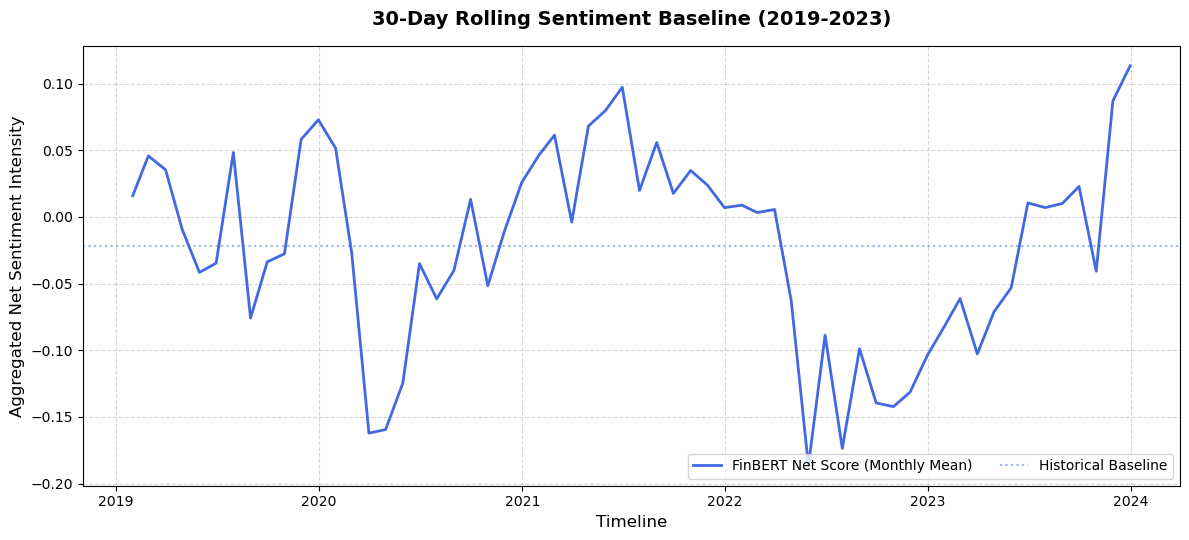

In [23]:
#Sentiment Trajectory Plot - Dataset B
time_df = datasetB_fin_sentiment[['date', 'finbert_net_score']].copy()
time_df['date'] = pd.to_datetime(time_df['date'])
time_df.set_index('date', inplace=True)

#Resample to Monthly Average to smooth out daily noise for a clean display
monthly_sentiment = time_df.resample('ME').mean() #Month End

plt.figure(figsize=(12, 5.5))
plt.plot(monthly_sentiment.index, monthly_sentiment['finbert_net_score'], label='FinBERT Net Score (Monthly Mean)', color='royalblue', linewidth=2)
plt.axhline(y=monthly_sentiment['finbert_net_score'].mean(), color='royalblue', linestyle=':', alpha=0.5, label='Historical Baseline')
plt.title('30-Day Rolling Sentiment Baseline (2019-2023)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Aggregated Net Sentiment Intensity', fontsize=12)
plt.legend(loc='lower right', frameon=True, ncol=2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('finbert_macro_sentiment_timelineB.png', dpi=300)
plt.show()

The above sentiment projection provides immediate, empirical proof that the models are not just calculating random noise but actively capturing macro-economic reality. The significant dip in early March 2020 reflects an unprecedented economy shock as the COVID-19 pandemic triggered widespread lockdowns. The financial markets reacted with extreme volatility, leading to the fastest bear market. This means that during this period, the text corpus was heavily saturated with high-intensity negative financial vocabulary. Both the models successfully picked up on this shift.

The Sentiment Rebound (Late 2020–2021)represents the massive influx of media coverage surrounding central bank stimulus packages, technology sector growth, and economic reopening narratives.In 2022, there is a more gradual prolonged dip which corresponds to the Federal Reserve's aggressive interest rate hiking cycle and the 2022 bear market.

Seeing these macroeconomic milestones reflected perfectly validates the model's capacity to extract macro-sentimental anomalies from unstructured text before these features are transitioned into the predictive modeling framework.

In [24]:
#Saving Data with Sentiment Scores
output_path1 = r'C:\Users\USER\PycharmProjects\ThesisProject\Data\News\DatasetA_Fin_Sentiment_Score.csv'
output_path2 = r'C:\Users\USER\PycharmProjects\ThesisProject\Data\News\DatasetB_Fin_Sentiment_Score.csv'
datasetA_fin_sentiment.to_csv(output_path1, index=False)
datasetB_fin_sentiment.to_csv(output_path2, index=False)